In [1]:
import pandas as pd
df = pd.read_csv('D:\TicketingPlatform\data\synthetic_tickets.csv')

In [2]:
df.head()

,ticket_id,description,teams,priority,resolution_time,application,environment,category,status,affected_users,impact_scope,created_at,resolved_at,root_cause
0,1,URGENT - Slow query execution observed causing...,Database,P1,92,Oracle DB,Production,Database,Cancelled,717,site,2025-09-19 00:54:29,2025-09-19 02:26:29,Slow Query Execution
1,2,Report shows issue is reported by a department...,Middleware,P2,253,Kafka,Production,Middleware,Resolved,65,department,2025-07-22 17:20:30,2025-07-22 21:33:30,Middleware Service Down
2,3,URGENT - Application deployment failed blockin...,Batch,P3,195,Autosys,Production,Batch Failure,Closed,61,department,2025-08-18 06:07:37,2025-08-18 09:22:37,ETL Failure
3,4,Report shows issue is affecting a large user g...,Middleware,P1,48,Kafka,Production,Middleware,Cancelled,865,site,2025-04-06 07:44:32,2025-04-06 08:32:32,Thread Pool Exhaustion
4,5,Report shows issue is affecting a large user g...,Wintel,P2,184,Active Directory,Production,Authentication,Resolved,124,site,2026-01-26 16:07:44,2026-01-26 19:11:44,Active Directory Failure


In [3]:
df.describe()

,ticket_id,resolution_time,affected_users
count,20000.000000,20000.000000,20000.000000
mean,10000.500000,151.637350,674.025600
std,5773.647028,134.742913,1809.412447
min,1.000000,8.000000,1.000000
25%,5000.750000,40.000000,7.000000
50%,10000.500000,142.000000,46.000000
75%,15000.250000,232.000000,310.000000
max,20000.000000,1810.000000,10000.000000


<Axes: xlabel='teams'>

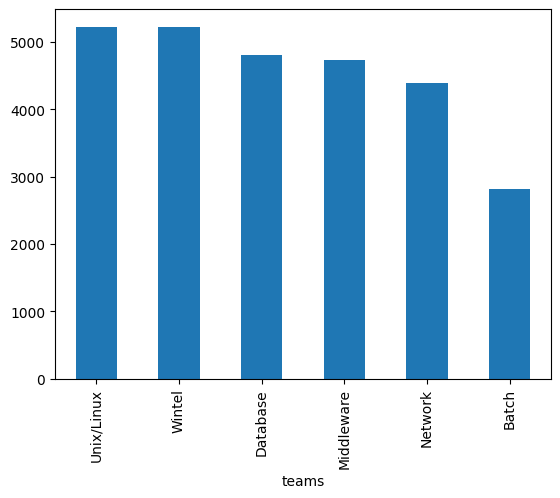

In [4]:
team_counts = (
    df["teams"]
    .str.split(",")
    .explode()
    .value_counts()
)
import matplotlib.pyplot as plt
team_counts.plot.bar()

<Axes: xlabel='priority', ylabel='count'>

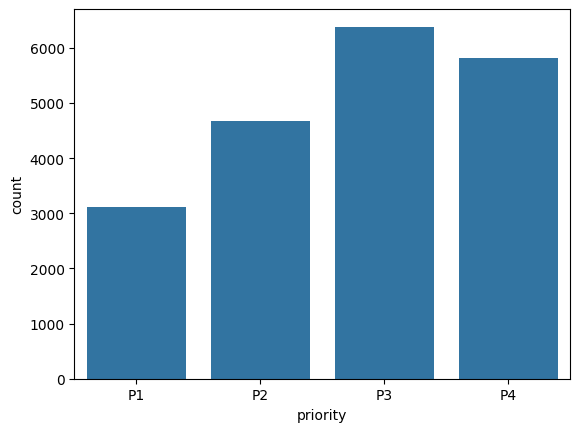

In [5]:
df["priority"].value_counts(normalize=True)*100
import seaborn as sns
sns.countplot(data=df,x="priority")

In [6]:
df["resolution_time"].describe()

count    20000.000000
mean       151.637350
std        134.742913
min          8.000000
25%         40.000000
50%        142.000000
75%        232.000000
max       1810.000000
Name: resolution_time, dtype: float64

151.63735
142.0
339.0


<Axes: xlabel='resolution_time', ylabel='Count'>

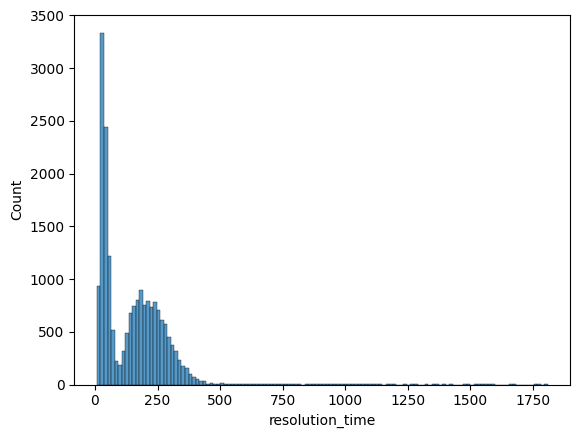

In [7]:
print(df["resolution_time"].mean()) 
print(df["resolution_time"].median())
print(df["resolution_time"].quantile(.95))
sns.histplot(df["resolution_time"])

In [8]:
df.groupby("priority")["resolution_time"].mean()

priority
P1     44.390550
P2    180.370220
P3    282.418728
P4     42.392477
Name: resolution_time, dtype: float64

In [9]:
team_exploded = (
    df.assign(
        team=df["teams"].str.split(",")
    )
    .explode("team")
)
team_exploded.groupby("team")[
    "resolution_time"
].mean()

team
Batch         136.235648
Database      179.380387
Middleware    158.501164
Network       143.463148
Unix/Linux    145.742534
Wintel        136.863602
Name: resolution_time, dtype: float64

<Axes: xlabel='application'>

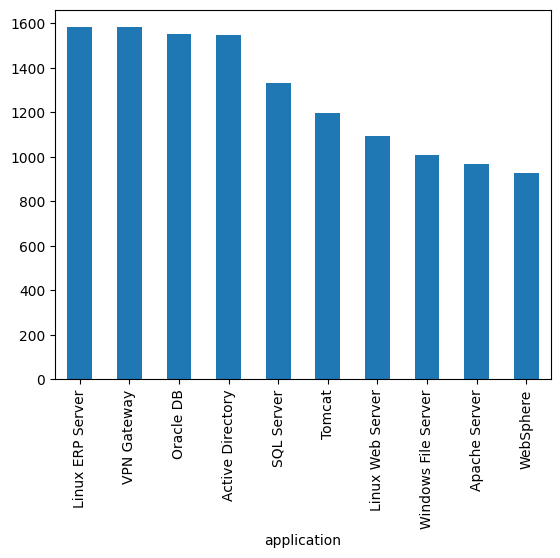

In [10]:
top = df["application"].value_counts().head(10)
top.plot.bar()


In [11]:
df["root_cause"].value_counts()

root_cause
Account Lockout              1391
DNS Service Failure          1379
Active Directory Failure     1374
Listener Failure             1250
Slow Query Execution         1240
Message Queue Failure        1205
Database Lock                1175
Middleware Service Down      1168
Thread Pool Exhaustion       1147
Filesystem Full              1077
Firewall Misconfiguration    1074
Network Congestion           1053
CPU Saturation               1046
Kernel Panic                 1042
VPN Tunnel Failure           1028
Memory Exhaustion            1002
Scheduler Failure             461
ETL Failure                   446
Batch Timeout                 442
Name: count, dtype: int64

In [12]:
df["created_at"] = pd.to_datetime(
    df["created_at"]
)

<Axes: xlabel='month'>

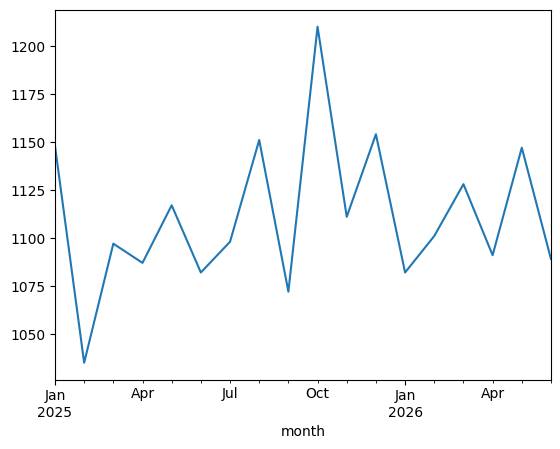

In [13]:
df["month"] = (
    df["created_at"]
    .dt.to_period("M")
)
monthly = (
    df.groupby("month")
      .size()
)
monthly.plot.line()

In [14]:
df.groupby("priority")[
    "affected_users"
].mean()

priority
P1    3534.996786
P2     447.695791
P3      53.559505
P4       7.805222
Name: affected_users, dtype: float64

In [15]:
df.groupby("priority")[
    "resolution_time"
].mean()

priority
P1     44.390550
P2    180.370220
P3    282.418728
P4     42.392477
Name: resolution_time, dtype: float64

In [16]:
pd.crosstab(
    df.environment,
    df.priority
)

priority,P1,P2,P3,P4
environment,,,,
Development,275,471,651,590
Production,2191,3262,4489,4095
UAT,645,948,1246,1137


In [17]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)
df = pd.read_csv("D:\TicketingPlatform\data\synthetic_tickets.csv")
X = df["description"]
y = df["priority"]
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)
model = Pipeline([
    ("tfidf", TfidfVectorizer(
        max_features=5000,
        ngram_range=(1,2)
    )),
    ("clf", LogisticRegression(
        max_iter=1000
    ))
])
model.fit(X_train, y_train)
pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, pred))
print("\nClassification Report\n")
print(classification_report(y_test, pred))
print("\nConfusion Matrix\n")
print(confusion_matrix(y_test, pred))

Accuracy: 0.6455

Classification Report

              precision    recall  f1-score   support

          P1       0.80      0.58      0.67       622
          P2       0.56      0.59      0.57       936
          P3       0.59      0.54      0.57      1277
          P4       0.70      0.84      0.76      1165

    accuracy                           0.65      4000
   macro avg       0.66      0.64      0.64      4000
weighted avg       0.65      0.65      0.64      4000


Confusion Matrix

[[362 255   5   0]
 [ 88 549 289  10]
 [  3 173 693 408]
 [  0   5 182 978]]


In [18]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import MultiLabelBinarizer
from sklearn.metrics import f1_score
df = pd.read_csv("D:\TicketingPlatform\data\synthetic_tickets.csv")
df["teams"] = df["teams"].apply(
    lambda x: x.split(",")
)
mlb = MultiLabelBinarizer()

Y = mlb.fit_transform(df["teams"])

X_train, X_test, y_train, y_test = train_test_split(
    df["description"],
    Y,
    test_size=0.2,
    random_state=42
)

model = Pipeline([
    (
        "tfidf",
        TfidfVectorizer(
            max_features=5000,
            ngram_range=(1,2)
        )
    ),
    (
        "clf",
        OneVsRestClassifier(
            LogisticRegression(max_iter=1000)
        )
    )
])

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(
    "Micro F1:",
    f1_score(
        y_test,
        pred,
        average="micro"
    )
)

print(
    "Macro F1:",
    f1_score(
        y_test,
        pred,
        average="macro"
    )
)

Micro F1: 0.7147102526002972
Macro F1: 0.6945224854898319


In [19]:
import pandas as pd

from sklearn.compose import ColumnTransformer

from sklearn.pipeline import Pipeline

from sklearn.model_selection import train_test_split

from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    r2_score
)

df = pd.read_csv(
    "D:\TicketingPlatform\data\synthetic_tickets.csv"
)

X = df[
    [
        "description",
        "priority",
        "application"
    ]
]

y = df["resolution_time"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

preprocessor = ColumnTransformer([
    (
        "text",
        TfidfVectorizer(max_features=5000),
        "description"
    ),
    (
        "cat",
        OneHotEncoder(
            handle_unknown="ignore"
        ),
        [
            "priority",
            "application"
        ]
    )
])

model = Pipeline([
    ("prep", preprocessor),
    (
        "rf",
        RandomForestRegressor(
            n_estimators=200,
            random_state=42
        )
    )
])

model.fit(X_train, y_train)

pred = model.predict(X_test)

print(
    "MAE:",
    mean_absolute_error(
        y_test,
        pred
    )
)

print(
    "R2:",
    r2_score(
        y_test,
        pred
    )
)

MAE: 40.663643229166674
R2: 0.5358358614409067
